In [3]:
# Load the ECG data
data = np.loadtxt('data/ECGu.txt')

# Display it
print (data)
print("Number of points:", len(data))

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
Number of points: 6500


# Arrival point : 
Detect heartbeats and compute heart rate from the raw ECG signal.

# Starting point : 
Raw voltage values loaded from 'ECGu.txt'

# Steps : 
1. Load the data
2. Plot the raw ECG data
3. Convert to mV / seconds
4. Plot rescaled data 
5. Rename vars, refactor, docstrings


In [4]:
import numpy as np  
import matplotlib.pyplot as plt

In [9]:
raw_ecg = np.loadtxt('data/ECGu.txt')

In [10]:
print(raw_ecg)
print(raw_ecg.shape)

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


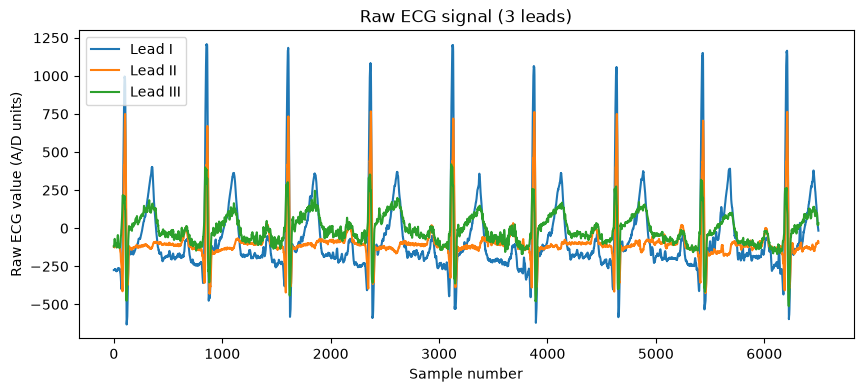

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(raw_ecg)
plt.xlabel("Sample number")
plt.ylabel("Raw ECG value (A/D units)")
plt.title("Raw ECG signal (3 leads)")
plt.legend(["Lead I", "Lead II", "Lead III"])
plt.show()

plt.figure(figsize=(10, 4)) - Crée une nouvelle figure (une nouvelle "fenêtre" de graphique) avec une taille de 10 pouces de large sur 4 pouces de haut. Sans ça, matplotlib utiliserait une taille par défaut (souvent trop petite/carrée), ce qui rendrait un signal ECG (qui s'étale sur l'axe du temps) difficile à lire.

plt.plot(raw_ecg) - Trace le graphique. raw_ecg est un tableau numpy de forme (6500, 3) — 6500 lignes (échantillons), 3 colonnes (leads I, II, III). Quand tu donnes un tableau 2D à plt.plot(), matplotlib trace automatiquement une courbe par colonne, en utilisant l'index de ligne (0, 1, 2, ..., 6499) comme axe des x. Résultat : 3 courbes superposées sur le même graphique, une par lead.

plt.xlabel("Sample number") - Ajoute un texte sous l'axe horizontal (x) pour dire ce qu'il représente : ici, le numéro de l'échantillon (0 à 6499), puisqu'on n'a pas encore converti ça en secondes.

plt.ylabel("Raw ECG value (A/D units)") : Ajoute un texte à côté de l'axe vertical (y) : les valeurs tracées sont les valeurs brutes du convertisseur analogique-numérique (A/D), pas encore converties en millivolts (d'où "raw" et "A/D units" — pas encore une unité physique réelle).

plt.title("Raw ECG signal (3 leads)") : Ajoute un titre en haut du graphique, pour que n'importe qui comprenne immédiatement ce que montre la figure sans avoir à lire le code.


plt.legend(["Lead I", "Lead II", "Lead III"]) : Ajoute une légende (petite boîte) qui associe chaque couleur de courbe à un nom. Comme plt.plot() a tracé 3 courbes dans l'ordre des colonnes de raw_ecg, cette liste doit être dans le même ordre : colonne 0 = Lead I, colonne 1 = Lead II, colonne 2 = Lead III.

plt.show() : Affiche le graphique final à l'écran.

In [15]:
print("Min value:", raw_ecg.min())
print("Max value:", raw_ecg.max())

Min value: -632.0
Max value: 1206.0


# Check : 
The plot shows 3 overlapping curves, one per lead, which matches raw_ecg.shape = (6500, 3). 
The x-axis goes up to 6500 samples as expected. 
The y-axis values range roughly from -500 to 1250, which is 
consistent with value check just performed. The signal shows a repeating pattern typical of heartbeats, rather than random noise, which suggests the data was loaded and plotted correctly.

In [20]:
# Convert raw ECG values to millivolts
# A/D converter gain: 1.024 µV per unit
AD_GAIN_UV = 1.024  # microvolts per raw unit
ecg_mV = raw_ecg * AD_GAIN_UV / 1000  # convert to millivolts

**Do we have the needed time information in our data?**

No. The raw data file `ECGu.txt` only contains 3 columns (the values for Lead I, II, and III) — there is no timestamp column. Since the time information is not directly available, we cannot simply divide an  existing column by 1000 as the formula in 5.1.2 suggests.

Instead, we reconstruct the time axis ourselves using the known sampling frequency (1000 Hz): each sample corresponds to 1/1000th of a second, so the time of sample `i` is `i / 1000` seconds. This is what `time_axis_s = np.arange(n_samples) / SAMPLING_FREQ_HZ` computes.

In [21]:
# Build the time axis in seconds
# Sampling frequency: 1000 Hz
SAMPLING_FREQ_HZ = 1000
n_samples = raw_ecg.shape[0]
time_axis_s = np.arange(n_samples) / SAMPLING_FREQ_HZ

n_samples = raw_ecg.shape[0] : Récupère le nombre total d'échantillons dans tes données.
raw_ecg.shape donne la forme complète du tableau, ici (6500, 3).
.shape[0] prend le premier élément de ce tuple (collection ordonnée de valeurs entre parenthèses : 6500 = nb lignes et 3 = nb colonnes), donc 6500 — le nombre de lignes (= nombre d'échantillons dans le temps). 

In [22]:
print("ecg_mV range:", ecg_mV.min(), "to", ecg_mV.max())
print("time_axis_s range:", time_axis_s[0], "to", time_axis_s[-1], "seconds")

ecg_mV range: -0.647168 to 1.234944
time_axis_s range: 0.0 to 6.499 seconds


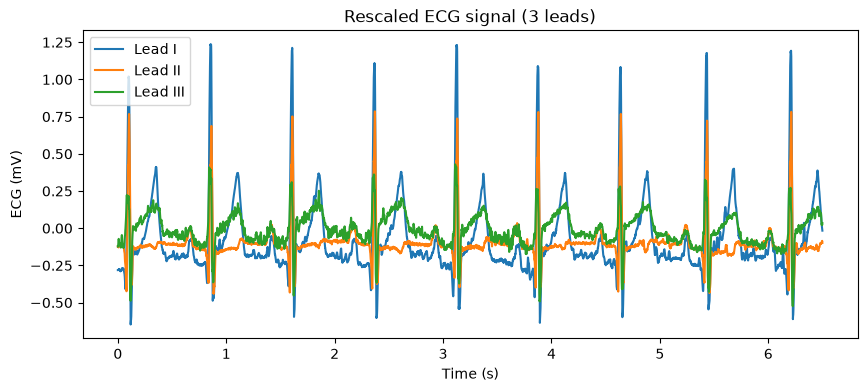

In [23]:
# Plot the rescaled ECG data
plt.figure(figsize=(10, 4))
plt.plot(time_axis_s, ecg_mV)
plt.xlabel("Time (s)")
plt.ylabel("ECG (mV)")
plt.title("Rescaled ECG signal (3 leads)")
plt.legend(["Lead I", "Lead II", "Lead III"])
plt.show()

plt.plot(time_axis_s, ecg_mV) — trace ecg_mV (y) en fonction de time_axis_s (x). Comme ecg_mV a 3 colonnes (une par lead), matplotlib trace automatiquement 3 courbes, chacune contre le même axe de temps.
plt.xlabel("Time (s)") — l'axe x est maintenant en secondes réelles, pas en numéro d'échantillon (différence avec 4.4).
plt.ylabel("ECG (mV)") — l'axe y est maintenant en millivolts, une vraie unité physique, pas en unités A/D brutes.
Le reste (titre, légende, figsize) est identique à la version brute.

# Checking the rescaled plot

**Are the number of timeseries correct?** 
3, matching `ecg_mV.shape[1] = 3` (Lead I, II, III).

**Are the number of samples correct?**
6500, matching `ecg_mV.shape[0]` and `len(time_axis_s)`.

**Are the values in the plot consistent with the expected range of ECG signals?** **What are the expected values for a normal ECG signal? Find a reference to support your answer.**
Approximately -0.65 to +1.25 mV. According to normal ECG  reference values (Rosenthal, L., *Normal Electrocardiography (ECG) Intervals*, Medscape, updated Jun 19, 2026 - https://emedicine.medscape.com/article/2172196-overview), a normal QRS amplitude is typically above 0.5 mV in standard leads, with an upper limit of normal around 2.5-3.0 mV. Our observed range fits comfortably within these bounds, supporting that the rescaling was done correctly.

**Other questions : Is the implied heart rate physiologically plausible?** 
Checking the sample count and value range only confirms the numbers are mathematically consistent — it doesn't confirm the signal actually looks like a real heartbeat. Since a real ECG shows a repeating pattern (one peak per heartbeat), we can cross-check the data by estimating the heart rate directly from the signal and comparing it to a known normal range (60-100 bpm at rest).

Here, visually counting the peaks on the plot over the 6.5-second window gives peaks, which corresponds to:

    9 peaks / 6.5 seconds × 60 seconds/minute ≈ 83 bpm

This falls within the normal resting heart rate range (60-100 bpm), which supports that the signal was loaded and rescaled correctly, and that it genuinely represents heartbeat activity rather than an arbitrary waveform.


# Refactoring: a reusable plotting function

The raw and rescaled ECG plots use almost identical code, differing only in axis labels, title, and data. To avoid duplication and make future changes easier (e.g. if we want to add more leads or change the plot style), we factor this into a single `plot_ecg` function.

In [41]:
def plot_ecg(time_axis, ecg_leads, title="ECG Signal", xlabel="Time (s)", ylabel="ECG (mV)",
             lead_names=("Lead I", "Lead II", "Lead III")):
    """Plot ECG signal(s) as a line chart with labeled axes, title, and legend.

    Used to avoid duplicating plotting code between the raw and rescaled 
    ECG plots — only the data and axis labels change between calls.

    One line is plotted per lead, using the column order in ecg_data 
    matched to the order of lead_names.
    """
    plt.figure(figsize=(10, 4))

    for i, lead_name in enumerate(lead_names):
        plt.plot(time_axis, ecg_leads[:, i], label=lead_name)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

### Explication de `plot_ecg`

def plot_ecg(time_axis, ecg_data, title="ECG Signal", xlabel="Time (s)", 
             ylabel="ECG (mV)", lead_names=("Lead I", "Lead II", "Lead III")):
→ time_axis et ecg_data sont obligatoires. Les autres ont une valeur par 
défaut, donc optionnels à l'appel.

"""..."""
→ Docstring : documentation de la fonction (ignorée à l'exécution).

plt.figure(figsize=(10, 4))
→ Crée une figure de 10x4 pouces.

for i, lead_name in enumerate(lead_names):
→ Parcourt chaque nom de lead avec son index (i = 0, 1, 2...).

    plt.plot(time_axis, ecg_data[:, i], label=lead_name)
→ ecg_data[:, i] = toutes les lignes, colonne i uniquement (un seul lead).
  Trace cette courbe avec son nom directement attaché via label=.

plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
→ Ajoute les labels et le titre passés en paramètres.

plt.legend()
→ Affiche la légende, en récupérant automatiquement les label= de la boucle.

plt.show()
→ Affiche le graphique.

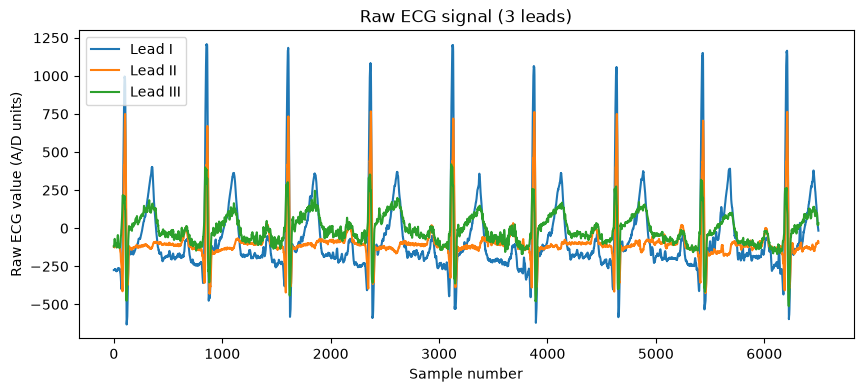

In [42]:
plot_ecg(
    time_axis=np.arange(raw_ecg.shape[0]),
    ecg_leads=raw_ecg,
    title="Raw ECG signal (3 leads)",
    xlabel="Sample number",
    ylabel="Raw ECG value (A/D units)"
)

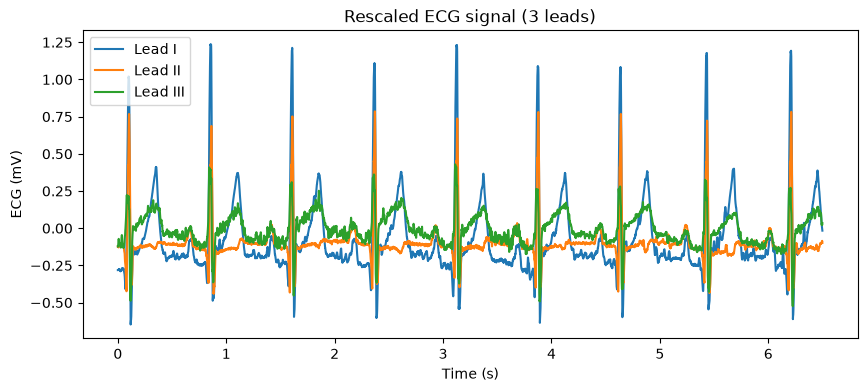

In [43]:
plot_ecg(
    time_axis=time_axis_s,
    ecg_leads=ecg_mV,
    title="Rescaled ECG signal (3 leads)",
    xlabel="Time (s)",
    ylabel="ECG (mV)"
)